# Sentence-Level Speech Recognition using LSTM

## Objective
Build a speech recognition model that converts spoken audio into text using
MFCC feature extraction and an LSTM neural network.

## Dataset
LibriSpeech - train-clean-100

## Technologies Used
- Python
- PyTorch
- Librosa
- NumPy
- Pandas

## Workflow
1. Dataset Loading
2. Data Exploration
3. Data Preprocessing
4. Feature Extraction (MFCC)
5. Model Development (LSTM)
6. Training and Evaluation
7. Speech-to-Text Demo# Sentence-Level Speech Recognition using LSTM

## Objective
Build a speech recognition model that converts spoken audio into text using
MFCC feature extraction and an LSTM neural network.

## Dataset
LibriSpeech - train-clean-100

## Technologies Used
- Python
- PyTorch
- Librosa
- NumPy
- Pandas

## Workflow
1. Dataset Loading
2. Data Exploration
3. Data Preprocessing
4. Feature Extraction (MFCC)
5. Model Development (LSTM)
6. Training and Evaluation
7. Speech-to-Text Demo

In [2]:
# ============================================================
# Step 1 — Import Required Libraries
# ============================================================

# System utilities
import os

# Data handling
import numpy as np
import pandas as pd

# Audio processing
import librosa

# Visualization
import matplotlib.pyplot as plt

# Deep learning (PyTorch)
import torch
import torch.nn as nn

# Progress bar
from tqdm import tqdm

In [3]:
# ============================================================
# Step 2 — Configure Dataset Path
# ============================================================

# Path where the LibriSpeech dataset was extracted
DATASET_PATH = "../data/raw/LibriSpeech/train-clean-100"

# Verify dataset structure
# Expected output: speaker folders such as ['19', '26', '27', ...]
print(os.listdir(DATASET_PATH)[:5])

['103', '1034', '1040', '1069', '1081']


In [4]:
# ============================================================
# Step 3 — Load LibriSpeech Dataset
# ============================================================

# Each transcript file (.trans.txt) contains mappings between
# audio IDs and the corresponding text transcripts.
#
# Example line inside transcript file:
# 19-198-0000 THE VERY FIRST THING

data = []

for root, dirs, files in os.walk(DATASET_PATH):

    for file in files:

        if file.endswith(".trans.txt"):

            transcript_path = os.path.join(root, file)

            with open(transcript_path, "r") as f:
                lines = f.readlines()

            for line in lines:

                parts = line.strip().split(" ")

                # Audio file identifier
                audio_id = parts[0]

                # Transcript text
                text = " ".join(parts[1:]).lower()

                # Construct full audio file path
                audio_file = os.path.join(root, audio_id + ".flac")

                data.append({
                    "audio_path": audio_file,
                    "text": text
                })

In [5]:
# ============================================================
# Step 4 — Convert Dataset to DataFrame
# ============================================================

df = pd.DataFrame(data)

print("Total samples:", len(df))

# Preview dataset
df.head()

Total samples: 28539


,audio_path,text
0,../data/raw/LibriSpeech/train-clean-100\103\12...,chapter one missus rachel lynde is surprised m...
1,../data/raw/LibriSpeech/train-clean-100\103\12...,that had its source away back in the woods of ...
2,../data/raw/LibriSpeech/train-clean-100\103\12...,for not even a brook could run past missus rac...
3,../data/raw/LibriSpeech/train-clean-100\103\12...,and that if she noticed anything odd or out of...
4,../data/raw/LibriSpeech/train-clean-100\103\12...,but missus rachel lynde was one of those capab...


In [6]:
# ============================================================
# Step 5 — Inspect Sample Audio
# ============================================================

# Select a sample audio file
sample_audio = df.iloc[0]["audio_path"]

# Load audio using librosa
audio, sr = librosa.load(sample_audio, sr=None)

print("Sampling Rate:", sr)
print("Audio Length:", len(audio))

Sampling Rate: 16000
Audio Length: 225360


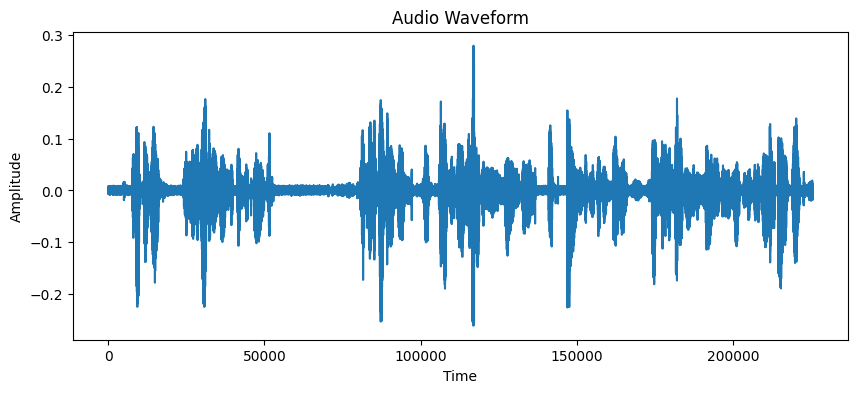

In [7]:
# ============================================================
# Step 6 — Visualize Audio Waveform
# ============================================================
# 
plt.figure(figsize=(10,4))
plt.plot(audio)

plt.title("Audio Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()

In [8]:
# ============================================================
# Step 7 — MFCC Feature Extraction
# ============================================================

# Speech recognition models cannot process raw audio signals.
# Therefore we extract MFCC (Mel Frequency Cepstral Coefficients),
# which represent important speech characteristics.

def extract_mfcc(audio_path):

    # Load audio at 16kHz
    audio, sr = librosa.load(audio_path, sr=16000)

    # Extract MFCC features
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    return mfcc

In [9]:
# ============================================================
# Step 8 — Extract MFCC Features from Sample Audio
# ============================================================

mfcc = extract_mfcc(sample_audio)

print("MFCC shape:", mfcc.shape)

MFCC shape: (40, 441)


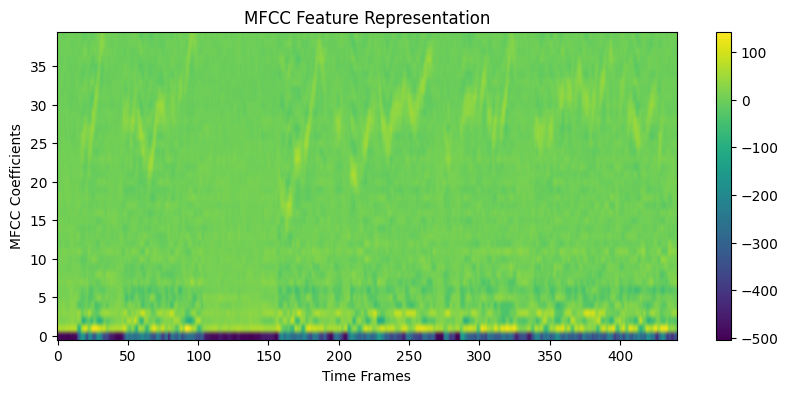

In [10]:
# ============================================================
# Step 9 — Visualize MFCC Features
# ============================================================

plt.figure(figsize=(10,4))

plt.imshow(mfcc, aspect="auto", origin="lower")

plt.title("MFCC Feature Representation")
plt.xlabel("Time Frames")
plt.ylabel("MFCC Coefficients")

plt.colorbar()

plt.show()

In [11]:
# ============================================================
# Step 10 — Prepare Input for LSTM Model
# ============================================================

# LSTM expects input shape:
# (batch_size, time_steps, features)

mfcc_input = mfcc.T

print("LSTM input shape:", mfcc_input.shape)

LSTM input shape: (441, 40)


In [12]:
# ============================================================
# Step 11 — Define LSTM Speech Recognition Model
# ============================================================

class SpeechRecognitionModel(nn.Module):

    def __init__(self, input_size=40, hidden_size=256, num_layers=2):

        super(SpeechRecognitionModel, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_size * 2, 30)

    def forward(self, x):

        out, _ = self.lstm(x)
        out = self.fc(out)

        return out

In [13]:
# ============================================================
# Step 12 — Initialize Model
# ============================================================

model = SpeechRecognitionModel()

print(model)

SpeechRecognitionModel(
  (lstm): LSTM(40, 256, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=512, out_features=30, bias=True)
)


In [14]:
# ============================================================
# Step 13 — Convert MFCC Features to PyTorch Tensor
# ============================================================

# LSTM expects input shape:
# (batch_size, time_steps, features)

# Convert MFCC matrix to correct format
mfcc_tensor = torch.tensor(mfcc_input).unsqueeze(0).float()

print("Tensor shape:", mfcc_tensor.shape)

Tensor shape: torch.Size([1, 441, 40])


In [15]:
# ============================================================
# Step 14 — Test Model Forward Pass
# ============================================================

# Pass MFCC tensor through the model
output = model(mfcc_tensor)

print("Model output shape:", output.shape)

Model output shape: torch.Size([1, 441, 30])


In [16]:
# ============================================================
# Step 15 — Prepare Training Dataset (8000 Samples)
# ============================================================

# Select 2000 samples from dataset
subset_df = df.sample(8000).reset_index(drop=True)

mfcc_features = []
transcripts = []

for _, row in tqdm(subset_df.iterrows(), total=len(subset_df)):

    audio_path = row["audio_path"]
    text = row["text"]

    # Extract MFCC features
    mfcc = extract_mfcc(audio_path)

    # Transpose for LSTM input
    mfcc = mfcc.T

    mfcc_features.append(torch.tensor(mfcc).float())
    transcripts.append(text)

print("Total training samples:", len(mfcc_features))

100%|██████████| 8000/8000 [04:33<00:00, 29.21it/s]

Total training samples: 8000


In [17]:
# ============================================================
# Step 16 — Create Character Vocabulary
# ============================================================

characters = list("abcdefghijklmnopqrstuvwxyz '")

char_to_index = {c:i+1 for i,c in enumerate(characters)}
index_to_char = {i:c for c,i in char_to_index.items()}

print("Vocabulary size:", len(characters))

Vocabulary size: 28


In [18]:
# ============================================================
# Step 17 — Encode Transcript Labels
# ============================================================

def encode_text(text):
    return [char_to_index[c] for c in text if c in char_to_index]

encoded_targets = [torch.tensor(encode_text(t)) for t in transcripts]

In [19]:
# ============================================================
# Step 18 — Pad MFCC Sequences
# ============================================================

from torch.nn.utils.rnn import pad_sequence

X = pad_sequence(mfcc_features, batch_first=True)

print("Input tensor shape:", X.shape)

Input tensor shape: torch.Size([8000, 551, 40])


In [20]:
# ============================================================
# Step 19 — Define CTC Loss and Optimizer
# ============================================================

ctc_loss = nn.CTCLoss(blank=0)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [21]:
# ============================================================
# Step 20 — Check if Trained Model Already Exists
# ============================================================

model_path = "../model/lstm_ctc_model.pth"

if os.path.exists(model_path):

    print("Trained model found. Loading model...")

    model.load_state_dict(torch.load(model_path))

    print("Model loaded successfully. Skipping training.")

else:

    print("No trained model found. Starting training...")



if not os.path.exists(model_path):

    epochs = 15

    for epoch in range(epochs):

        total_loss = 0

        for i in tqdm(range(len(X))):

            inputs = X[i].unsqueeze(0)

            outputs = model(inputs)

            log_probs = outputs.log_softmax(2)

            target = encoded_targets[i]

            input_lengths = torch.tensor([outputs.size(1)])
            target_lengths = torch.tensor([len(target)])

            loss = ctc_loss(
                log_probs.transpose(0,1),
                target,
                input_lengths,
                target_lengths
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} Loss:", total_loss)

No trained model found. Starting training...


100%|██████████| 8000/8000 [47:34<00:00,  2.80it/s]  


Epoch 1/15 Loss: 16082.144500851631


100%|██████████| 8000/8000 [1:01:30<00:00,  2.17it/s]


Epoch 2/15 Loss: 12558.2118511796


...

Epoch 13/15 Loss: 8391.92840975523


100%|██████████| 8000/8000 [53:34<00:00,  2.49it/s] 


Epoch 14/15 Loss: 8310.640791386366


100%|██████████| 8000/8000 [53:00<00:00,  2.52it/s] 

Epoch 15/15 Loss: 8218.958821862936


In [22]:
# ============================================================
# Step 21 — Save Trained Model
# ============================================================

if not os.path.exists(model_path):

    torch.save(model.state_dict(), model_path)

    print("Model saved successfully.")

Model saved successfully.


In [23]:
# ============================================================
# Step 22 — Import Evaluation Metrics
# ============================================================

# jiwer library provides Word Error Rate and Character Error Rate
from jiwer import wer, cer

In [24]:
# ============================================================
# Step 23 — Decode Model Predictions (CTC Decoding)
# ============================================================

def decode_prediction(output):

    predicted_indices = torch.argmax(output, dim=2)

    predicted_text = ""
    previous = None

    for idx in predicted_indices[0]:

        idx = idx.item()

        # Skip repeated characters (CTC rule)
        if idx != previous:

            if idx in index_to_char:
                predicted_text += index_to_char[idx]

        previous = idx

    return predicted_text

In [25]:
# ============================================================
# Step 24 — Generate Prediction
# ============================================================

# Select a sample from dataset
sample_audio = df.iloc[0]["audio_path"]
true_text = df.iloc[0]["text"]

# Extract MFCC
mfcc = extract_mfcc(sample_audio)
mfcc = mfcc.T

# Convert to tensor
mfcc_tensor = torch.tensor(mfcc).unsqueeze(0).float()

# Run model
output = model(mfcc_tensor)

# Decode prediction
predicted_text = decode_prediction(output)

print("Actual text:", true_text)
print("Predicted text:", predicted_text)

Actual text: chapter one missus rachel lynde is surprised missus rachel lynde lived just where the avonlea main road dipped down into a little hollow fringed with alders and ladies eardrops and traversed by a brook
Predicted text: chapter wane missis racil land d isurpries mssis reacill lrind ti ve cjust twred bhe aemmeine maine rod ticedow ng to a litele hallo fr ingge wut allthers and tlade syre gops ind fromverst ih e tleook 


In [26]:
# ============================================================
# Step 25 — Evaluate Model using WER and CER
# ============================================================

word_error = wer(true_text, predicted_text)
char_error = cer(true_text, predicted_text)

print("Word Error Rate (WER):", word_error)
print("Character Error Rate (CER):", char_error)

Word Error Rate (WER): 1.0
Character Error Rate (CER): 0.3880597014925373
